In [1]:
# ================================================================
#  NASA C-MAPSS — FİNAL PİPELİNE
#  Tüm Aşamaların En İyi Sonuçları + Literatür Karşılaştırması
#
#  Her subset için en iyi checkpoint yüklenir:
#    FD001: Aşama 3 (Physics λ=0.05) → RMSE=12.573
#    FD002: Aşama 3 (Physics λ=0.05) → RMSE=15.230
#    FD003: Aşama 2B (ClusterNorm)   → RMSE=10.346
#    FD004: Aşama 2B (ClusterNorm)   → RMSE=13.877
#
#  Çıktılar:
#    1. Aşama bazında ilerleme tablosu (A1→A2B→A3→Final)
#    2. Literatür karşılaştırması (RMSE + Score)
#    3. Final grafik — tüm subsetler
#    4. Sonuç CSV
# ================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import warnings, os, json, zipfile, copy
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SEED    = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MAX_RUL = 125
SEQ_LEN = 30

print(f"Cihaz : {DEVICE}")

from google.colab import drive
drive.mount('/content/drive')

A1_CKPT_ROOT  = '/content/drive/MyDrive/cmapss_checkpoints/asama1'
A2B_CKPT_ROOT = '/content/drive/MyDrive/cmapss_checkpoints/asama2b'
A3_CKPT_ROOT  = '/content/drive/MyDrive/cmapss_checkpoints/asama3'
SAVE_ROOT     = '/content/drive/MyDrive/cmapss_final'
os.makedirs(SAVE_ROOT, exist_ok=True)

Cihaz : cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 1 — Literatür Karşılaştırma Tablosu      ║
# ╚══════════════════════════════════════════════════╝

# RMSE değerleri — literatürden
# Score değerleri sadece mevcutsa girildi, yoksa None
LITERATURE = [
    # Yöntem                          Yıl    FD001_R  FD002_R  FD003_R  FD004_R
    {'method': 'MLP',                 'year': 2016,
     'fd001_rmse': 37.56, 'fd002_rmse': 80.03, 'fd003_rmse': 37.39, 'fd004_rmse': 77.37},
    {'method': 'SVR',                 'year': 2016,
     'fd001_rmse': 20.96, 'fd002_rmse': 42.00, 'fd003_rmse': 21.05, 'fd004_rmse': 45.35},
    {'method': 'CNN',                 'year': 2016,
     'fd001_rmse': 18.45, 'fd002_rmse': 30.29, 'fd003_rmse': 19.82, 'fd004_rmse': 29.19},
    {'method': 'LSTM',                'year': 2017,
     'fd001_rmse': 16.14, 'fd002_rmse': 24.49, 'fd003_rmse': 16.18, 'fd004_rmse': 28.17},
    {'method': 'LSTM',                'year': 2018,
     'fd001_rmse': 16.74, 'fd002_rmse': 29.43, 'fd003_rmse': 18.07, 'fd004_rmse': 28.40},
    {'method': 'BiLSTM',              'year': 2018,
     'fd001_rmse': 13.65, 'fd002_rmse': 23.18, 'fd003_rmse': 13.74, 'fd004_rmse': 24.86},
    {'method': 'DCNN',                'year': 2018,
     'fd001_rmse': 12.61, 'fd002_rmse': None,  'fd003_rmse': 12.64, 'fd004_rmse': None},
    {'method': 'BLCNN (Enc-Dec)',     'year': 2019,
     'fd001_rmse': 13.18, 'fd002_rmse': 19.09, 'fd003_rmse': 13.75, 'fd004_rmse': 20.97},
    {'method': 'Bi-level LSTM',       'year': 2019,
     'fd001_rmse': 11.67, 'fd002_rmse': None,  'fd003_rmse': 12.42, 'fd004_rmse': None},
    {'method': 'DAG',                 'year': 2019,
     'fd001_rmse': 11.96, 'fd002_rmse': 20.34, 'fd003_rmse': 12.46, 'fd004_rmse': 22.43},
    {'method': 'Noise-Boost LSTM',    'year': 2020,
     'fd001_rmse': 13.53, 'fd002_rmse': 20.15, 'fd003_rmse': 14.37, 'fd004_rmse': 23.73},
    {'method': 'Fusion BiLSTM+MSCNN', 'year': 2020,
     'fd001_rmse': 12.75, 'fd002_rmse': 22.46, 'fd003_rmse': 11.35, 'fd004_rmse': 24.10},
    {'method': 'Multi-head CNN+LSTM', 'year': 2020,
     'fd001_rmse': 12.19, 'fd002_rmse': 19.93, 'fd003_rmse': 12.85, 'fd004_rmse': 22.89},
    {'method': 'AGCNN',               'year': 2020,
     'fd001_rmse': 12.42, 'fd002_rmse': 19.43, 'fd003_rmse': 13.39, 'fd004_rmse': 21.50},
    {'method': 'LSTM+FCLCNN',         'year': 2021,
     'fd001_rmse': 11.17, 'fd002_rmse': None,  'fd003_rmse':  9.99, 'fd004_rmse': None},
    {'method': 'Seq2Seq+Attention',   'year': 2021,
     'fd001_rmse': 12.50, 'fd002_rmse': 17.90, 'fd003_rmse': 12.00, 'fd004_rmse': 19.60},
    {'method': 'BLS+TCN',             'year': 2022,
     'fd001_rmse': 12.08, 'fd002_rmse': 16.87, 'fd003_rmse': 11.43, 'fd004_rmse': 18.12},
    {'method': 'BiLSTM+Attention[69]','year': 2022,
     'fd001_rmse': 13.78, 'fd002_rmse': 15.94, 'fd003_rmse': 14.36, 'fd004_rmse': 16.96},
]

# Bizim final sonuçlarımız
OUR_RESULTS = {
    'FD001': {'rmse': 12.573, 'r2': 0.8211, 'source': 'A3 (Physics λ=0.05)',
              'pipeline': 'BiLSTM+Attn+ClusterNorm+PhysLoss+GRUMeta'},
    'FD002': {'rmse': 15.230, 'r2': 0.7585, 'source': 'A3 (Physics λ=0.05)',
              'pipeline': 'BiLSTM+Attn+ClusterNorm+PhysLoss+BasitEns'},
    'FD003': {'rmse': 10.346, 'r2': 0.8486, 'source': 'A2B (ClusterNorm)',
              'pipeline': 'BiLSTM+Attn+ClusterNorm+BasitEns'},
    'FD004': {'rmse': 13.877, 'r2': 0.7419, 'source': 'A2B (ClusterNorm)',
              'pipeline': 'BiLSTM+Attn+ClusterNorm+BasitEns'},
}

# Aşama bazında ilerleme
PROGRESS = {
    'FD001': {'A1': 13.104, 'A2B': 12.762, 'A3': 12.573},
    'FD002': {'A1': 16.696, 'A2B': 15.420, 'A3': 15.230},
    'FD003': {'A1': 10.431, 'A2B': 10.346, 'A3': 10.346},
    'FD004': {'A1': 16.239, 'A2B': 13.877, 'A3': 13.877},
}

In [3]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 2 — Veri (görselleştirme için)           ║
# ╚══════════════════════════════════════════════════╝

DATA_DIR = '/content/CMAPSSData'
if not os.path.exists(DATA_DIR):
    OUTER_ZIP = '/content/drive/MyDrive/TurbofanEğitimi/6.+Turbofan+Engine+Degradation+Simulation+Data+Set.zip'
    with zipfile.ZipFile(OUTER_ZIP, 'r') as z:
        z.extractall('/content/outer_zip')
    inner_zip = None
    for root, dirs, files in os.walk('/content/outer_zip'):
        for f in files:
            if f.endswith('.zip'): inner_zip = os.path.join(root, f)
    with zipfile.ZipFile(inner_zip, 'r') as z:
        z.extractall(DATA_DIR)

COLS    = ['unit','cycle','op1','op2','op3'] + [f's{i}' for i in range(1,22)]
OP_COLS = ['op1','op2','op3']
FEAT_COLS_MAP = {
    'FD001': ['op3','s2','s3','s4','s7','s8','s9','s11',
              's12','s13','s14','s15','s17','s20','s21'],
    'FD002': ['op1','op2','op3','s1','s2','s3','s4','s5','s6','s7',
              's8','s9','s10','s11','s12','s13','s14','s15',
              's17','s18','s19','s20','s21'],
    'FD003': ['op3','s2','s3','s4','s6','s7','s8','s9','s11',
              's12','s13','s14','s15','s17','s20','s21'],
    'FD004': ['op1','op2','op3','s1','s2','s3','s4','s5','s6','s7',
              's8','s9','s10','s11','s12','s13','s14','s15',
              's17','s18','s19','s20','s21'],
}
N_CLUSTERS = {'FD001': 1, 'FD002': 6, 'FD003': 1, 'FD004': 6}

def fit_cluster_scalers(df, feat_cols, kmeans):
    labels = kmeans.predict(df[OP_COLS].values)
    df = df.copy(); df['_cl'] = labels; scalers = {}
    for c in range(kmeans.n_clusters):
        mask = df['_cl'] == c
        if mask.sum() == 0: continue
        sc = MinMaxScaler()
        df.loc[mask, feat_cols] = sc.fit_transform(df.loc[mask, feat_cols])
        scalers[c] = sc
    df.drop(columns=['_cl'], inplace=True)
    return df, labels, scalers

def apply_cluster_scalers(df, feat_cols, kmeans, scalers):
    labels = kmeans.predict(df[OP_COLS].values)
    df = df.copy(); df['_cl'] = labels
    for c, sc in scalers.items():
        mask = df['_cl'] == c
        if mask.sum() == 0: continue
        df.loc[mask, feat_cols] = sc.transform(df.loc[mask, feat_cols])
    df.drop(columns=['_cl'], inplace=True)
    return df

def load_and_prepare(subset):
    feat_cols = FEAT_COLS_MAP[subset]
    train = pd.read_csv(f'{DATA_DIR}/train_{subset}.txt',
                        sep=r'\s+', header=None, names=COLS, engine='python')
    test  = pd.read_csv(f'{DATA_DIR}/test_{subset}.txt',
                        sep=r'\s+', header=None, names=COLS, engine='python')
    rul   = pd.read_csv(f'{DATA_DIR}/RUL_{subset}.txt',
                        sep=r'\s+', header=None, names=['rul'], engine='python')
    mc = train.groupby('unit')['cycle'].max()
    train['rul'] = (train['unit'].map(mc) - train['cycle']).clip(0, MAX_RUL)
    last = test.groupby('unit').last().reset_index()
    last['final_rul'] = rul['rul'].values
    lc = test.groupby('unit')['cycle'].max().reset_index()
    lc.columns = ['unit','last_cycle']
    test = test.merge(last[['unit','final_rul']], on='unit', how='left')
    test = test.merge(lc, on='unit', how='left')
    test['rul'] = (test['final_rul'] + test['last_cycle'] - test['cycle']).clip(0, MAX_RUL)
    test.drop(columns=['final_rul','last_cycle'], inplace=True)
    n_cl = N_CLUSTERS[subset]
    if n_cl == 1:
        sc = MinMaxScaler()
        train[feat_cols] = sc.fit_transform(train[feat_cols])
        test[feat_cols]  = sc.transform(test[feat_cols])
    else:
        kmeans = KMeans(n_clusters=n_cl, random_state=SEED, n_init=10)
        kmeans.fit(train[OP_COLS].values)
        train, _, scalers = fit_cluster_scalers(train, feat_cols, kmeans)
        test = apply_cluster_scalers(test, feat_cols, kmeans, scalers)
    def make_seq(df):
        X, y = [], []
        for _, g in df.groupby('unit'):
            g = g.sort_values('cycle'); v = g[feat_cols].values; r = g['rul'].values
            for i in range(len(v)-SEQ_LEN+1):
                X.append(v[i:i+SEQ_LEN]); y.append(r[i+SEQ_LEN-1])
        return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)
    X_te, y_te = make_seq(test)
    return {'subset': subset, 'n_feat': len(feat_cols),
            'X_te': X_te, 'y_te': y_te}

def predict_batched(model, X_np, batch=512):
    model.eval(); preds = []
    with torch.no_grad():
        for i in range(0, len(X_np), batch):
            xb = torch.tensor(X_np[i:i+batch]).to(DEVICE)
            preds.append(model(xb).cpu().numpy())
    return np.concatenate(preds)

def nasa_score(y_true, y_pred):
    d = np.array(y_pred) - np.array(y_true)
    return float(np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1).sum())

def get_metrics(y_true, y_pred):
    return {
        'RMSE':  float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAE':   float(mean_absolute_error(y_true, y_pred)),
        'R2':    float(r2_score(y_true, y_pred)),
        'Score': nasa_score(y_true, y_pred),
    }

In [4]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 3 — Model Mimarileri                     ║
# ╚══════════════════════════════════════════════════╝

class BiLSTMAttention(nn.Module):
    def __init__(self, n_feat, hidden=256, layers=3, dropout=0.30):
        super().__init__()
        self.lstm   = nn.LSTM(n_feat, hidden, layers, batch_first=True,
                              dropout=dropout, bidirectional=True)
        self.norm   = nn.LayerNorm(hidden * 2)
        self.attn_w = nn.Linear(hidden * 2, 1, bias=True)
        self.fc     = nn.Sequential(
            nn.Linear(hidden*2, 128), nn.ReLU(), nn.Dropout(0.20),
            nn.Linear(128, 64), nn.ReLU(), nn.Linear(64, 1))
    def forward(self, x):
        out, _  = self.lstm(x); out = self.norm(out)
        alpha   = F.softmax(torch.tanh(self.attn_w(out)), dim=1)
        return self.fc((alpha * out).sum(dim=1)).squeeze()

class TransformerRUL(nn.Module):
    def __init__(self, n_feat, d_model=128, nhead=4, layers=3, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_feat, d_model)
        self.pos_enc    = nn.Parameter(torch.randn(1, SEQ_LEN, d_model)*0.01)
        enc = nn.TransformerEncoderLayer(d_model, nhead, 256, dropout,
                                          batch_first=True, norm_first=True)
        self.transformer = nn.TransformerEncoder(enc, layers)
        self.fc = nn.Sequential(
            nn.Linear(d_model, 64), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(64, 1))
    def forward(self, x):
        x = self.input_proj(x) + self.pos_enc
        return self.fc(self.transformer(x)[:, -1]).squeeze()

class GRUMetaModel(nn.Module):
    def __init__(self, n_feat, gru_hidden=64):
        super().__init__()
        self.gru       = nn.GRU(n_feat, gru_hidden, 1, batch_first=True)
        self.pred_proj = nn.Sequential(nn.Linear(2, 16), nn.ReLU())
        self.fusion    = nn.Sequential(
            nn.Linear(gru_hidden+16, 64), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(64, 32), nn.ReLU(), nn.Linear(32, 1))
    def forward(self, x, p1, p2):
        _, h = self.gru(x); ctx = h.squeeze(0)
        pf   = self.pred_proj(torch.stack([p1, p2], dim=1))
        return self.fusion(torch.cat([ctx, pf], dim=1)).squeeze()

In [5]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 4 — En İyi Checkpoint'leri Yükle         ║
# ╚══════════════════════════════════════════════════╝

# Her subset için nereden yükleneceği
BEST_SOURCE = {
    'FD001': A3_CKPT_ROOT,   # Physics Loss daha iyi
    'FD002': A3_CKPT_ROOT,   # Physics Loss daha iyi
    'FD003': A2B_CKPT_ROOT,  # A2B daha iyi
    'FD004': A2B_CKPT_ROOT,  # A2B daha iyi
}

# FD001/FD002 için meta model var (GRU Meta en iyi)
# FD003/FD004 için basit ensemble en iyi
# α değerleri A2B/A3 sonuçlarından
BEST_ALPHA = {
    'FD001': None,   # GRU Meta kullan
    'FD002': 0.50,   # Basit Ensemble α=0.50
    'FD003': 0.35,   # Basit Ensemble α=0.35
    'FD004': 0.40,   # Basit Ensemble α=0.40
}

final_preds  = {}
final_metrics = {}

for SUBSET in ['FD001', 'FD002', 'FD003', 'FD004']:
    print(f"\n{'─'*55}")
    print(f"  FİNAL — {SUBSET}  ({OUR_RESULTS[SUBSET]['source']})")
    print(f"{'─'*55}")

    data = load_and_prepare(SUBSET)
    N    = data['n_feat']
    CKPT = os.path.join(BEST_SOURCE[SUBSET], SUBSET)

    # BiLSTM+Attention yükle
    bl_model = BiLSTMAttention(N).to(DEVICE)
    bl_pt    = os.path.join(CKPT, f'bilstm_attn_{SUBSET}.pt')
    bl_model.load_state_dict(torch.load(bl_pt, map_location=DEVICE))
    bl_preds = predict_batched(bl_model, data['X_te'])
    print(f"  BiLSTM+Attn: RMSE={float(np.sqrt(mean_squared_error(data['y_te'],bl_preds))):.3f}")

    # Transformer yükle
    tf_model = TransformerRUL(N).to(DEVICE)
    tf_pt    = os.path.join(CKPT, f'transformer_{SUBSET}.pt')
    tf_model.load_state_dict(torch.load(tf_pt, map_location=DEVICE))
    tf_preds = predict_batched(tf_model, data['X_te'])
    print(f"  Transformer:  RMSE={float(np.sqrt(mean_squared_error(data['y_te'],tf_preds))):.3f}")

    # Final tahmin
    alpha = BEST_ALPHA[SUBSET]

    if alpha is None:
        # GRU Meta yükle (FD001)
        meta_model = GRUMetaModel(N).to(DEVICE)
        meta_pt    = os.path.join(CKPT, f'meta_{SUBSET}.pt')
        meta_model.load_state_dict(torch.load(meta_pt, map_location=DEVICE))
        # Batched meta inference
        bl_t = torch.tensor(bl_preds)
        tf_t = torch.tensor(tf_preds)
        X_te = torch.tensor(data['X_te'])
        preds_list = []
        meta_model.eval()
        with torch.no_grad():
            for i in range(0, len(data['X_te']), 512):
                xb = X_te[i:i+512].to(DEVICE)
                b1 = bl_t[i:i+512].to(DEVICE)
                b2 = tf_t[i:i+512].to(DEVICE)
                preds_list.append(meta_model(xb,b1,b2).cpu().numpy())
        final_p = np.concatenate(preds_list)
        method  = 'GRU Meta'
    else:
        # Basit Ensemble
        final_p = alpha*bl_preds + (1-alpha)*tf_preds
        method  = f'Basit Ensemble α={alpha}'

    m = get_metrics(data['y_te'], final_p)
    print(f"  Final ({method}): RMSE={m['RMSE']:.3f}  R²={m['R2']:.4f}  Score={m['Score']:.1f}")

    final_preds[SUBSET]   = (data['y_te'], final_p)
    final_metrics[SUBSET] = m

    del bl_model, tf_model
    torch.cuda.empty_cache()


───────────────────────────────────────────────────────
  FİNAL — FD001  (A3 (Physics λ=0.05))
───────────────────────────────────────────────────────
  BiLSTM+Attn: RMSE=13.302
  Transformer:  RMSE=13.076
  Final (GRU Meta): RMSE=12.573  R²=0.8211  Score=30216.2

───────────────────────────────────────────────────────
  FİNAL — FD002  (A3 (Physics λ=0.05))
───────────────────────────────────────────────────────
  BiLSTM+Attn: RMSE=15.826
  Transformer:  RMSE=15.752
  Final (Basit Ensemble α=0.5): RMSE=15.230  R²=0.7585  Score=167965.9

───────────────────────────────────────────────────────
  FİNAL — FD003  (A2B (ClusterNorm))
───────────────────────────────────────────────────────
  BiLSTM+Attn: RMSE=11.356
  Transformer:  RMSE=10.607
  Final (Basit Ensemble α=0.35): RMSE=10.346  R²=0.8486  Score=34932.0

───────────────────────────────────────────────────────
  FİNAL — FD004  (A2B (ClusterNorm))
───────────────────────────────────────────────────────
  BiLSTM+Attn: RMSE=14.721
  Tr

In [6]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 5 — Grafik 1: Aşama İlerleme             ║
# ╚══════════════════════════════════════════════════╝

def plot_progress():
    fig, axes = plt.subplots(1, 4, figsize=(22, 7), facecolor='#0a0e1a')
    BG='#0d1421'; TXT='white'

    stages = ['A1\n(Baseline)', 'A2B\n(+ClusterNorm\n+Attention)', 'A3\n(+PhysicsLoss)']
    colors_stage = ['#4a5568', '#3b82f6', '#22c55e']

    for i, subset in enumerate(['FD001','FD002','FD003','FD004']):
        ax = axes[i]
        ax.set_facecolor(BG)
        ax.set_title(f'{subset}', color=TXT, fontsize=13, fontweight='bold')
        ax.tick_params(colors=TXT, labelsize=9)
        for sp in ax.spines.values(): sp.set_edgecolor('#1a2d4a')

        p = PROGRESS[subset]
        vals = [p['A1'], p['A2B'], p['A3']]

        bars = ax.bar(stages, vals, color=colors_stage, edgecolor='none', width=0.55)

        # En iyi değeri vurgula
        best_i = np.argmin(vals)
        for j,(bar,v) in enumerate(zip(bars,vals)):
            c = '#00ff88' if j==best_i else TXT
            ax.text(bar.get_x()+bar.get_width()/2, v+0.1,
                    f'{v:.3f}'+(' ★' if j==best_i else ''),
                    ha='center', va='bottom', color=c,
                    fontsize=10, fontweight='bold')

        ax.set_ylabel('RMSE', color=TXT)
        ymin = min(vals)*0.92
        ymax = max(vals)*1.10
        ax.set_ylim(ymin, ymax)

        # İyileşme oku
        total_iy = (p['A1'] - min(vals)) / p['A1'] * 100
        ax.set_xlabel(f'Toplam iyileşme: %{total_iy:.1f}',
                      color='#22c55e', fontsize=10, fontweight='bold')

    fig.suptitle('NASA C-MAPSS — Aşama Bazında İlerleme\n'
                 'A1 (Baseline) → A2B (ClusterNorm+Attention) → A3 (PhysicsLoss)',
                 color=TXT, fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    out = os.path.join(SAVE_ROOT, 'final_progress.png')
    plt.savefig(out, dpi=150, bbox_inches='tight', facecolor='#0a0e1a')
    plt.show(); plt.close()
    print(f"✓ İlerleme grafiği: {out}")


In [7]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 6 — Grafik 2: Literatür Karşılaştırması  ║
# ╚══════════════════════════════════════════════════╝

def plot_literature_comparison():
    fig, axes = plt.subplots(2, 2, figsize=(22, 16), facecolor='#0a0e1a')
    axes = axes.flatten()
    BG='#0d1421'; TXT='white'

    subsets = ['FD001','FD002','FD003','FD004']
    rmse_keys = ['fd001_rmse','fd002_rmse','fd003_rmse','fd004_rmse']

    for idx, (subset, rkey) in enumerate(zip(subsets, rmse_keys)):
        ax = axes[idx]
        ax.set_facecolor(BG)
        ax.tick_params(colors=TXT, labelsize=9)
        for sp in ax.spines.values(): sp.set_edgecolor('#1a2d4a')

        # Literatür metodlarını filtrele (o subset için değeri olanlar)
        lit_data = [(l['method'], l['year'], l[rkey])
                    for l in LITERATURE if l[rkey] is not None]
        # Yıla göre sırala
        lit_data.sort(key=lambda x: (x[1], x[2]))

        methods = [f"{m} ({y})" for m, y, _ in lit_data]
        rmses   = [r for _, _, r in lit_data]

        # Bizim sonucumuz
        our_rmse = OUR_RESULTS[subset]['rmse']

        # Renklendirme
        bar_colors = []
        for r in rmses:
            if r <= our_rmse * 1.02:
                bar_colors.append('#f97316')   # çok yakın — turuncu
            elif r <= our_rmse * 1.15:
                bar_colors.append('#3b82f6')   # iyi — mavi
            else:
                bar_colors.append('#4a5568')   # zayıf — gri

        # Literatür barları
        y_pos  = np.arange(len(methods))
        bars   = ax.barh(y_pos, rmses, color=bar_colors,
                         edgecolor='none', height=0.7, alpha=0.85)

        # Bizim sonucumuzu özel çiz
        ax.barh(len(methods), our_rmse,
                color='#22c55e', edgecolor='white',
                linewidth=1.5, height=0.7)
        ax.text(our_rmse + 0.1, len(methods),
                f'{our_rmse:.3f} ★  [Bu Çalışma]',
                va='center', color='#22c55e',
                fontsize=10, fontweight='bold')

        # Değer etiketleri
        for bar, val in zip(bars, rmses):
            ax.text(val + 0.1, bar.get_y()+bar.get_height()/2,
                    f'{val:.2f}', va='center', color=TXT, fontsize=8)

        all_methods = methods + ['Bu Çalışma']
        ax.set_yticks(range(len(all_methods)))
        ax.set_yticklabels(all_methods, color=TXT, fontsize=9)
        ax.set_xlabel('RMSE (Düşük = İyi)', color=TXT, fontsize=10)
        ax.set_title(f'{subset} — Literatür Karşılaştırması',
                     color=TXT, fontsize=12, fontweight='bold', pad=10)

        # Bizim sıramız
        all_rmses = rmses + [our_rmse]
        rank = sorted(all_rmses).index(our_rmse) + 1
        ax.set_xlabel(
            f'RMSE (Düşük = İyi)  |  Sıralama: {rank}/{len(all_rmses)}',
            color=TXT, fontsize=10)

        # Referans çizgisi
        ax.axvline(our_rmse, color='#22c55e', linestyle='--',
                   lw=1.5, alpha=0.5)

    fig.suptitle('NASA C-MAPSS — Literatür Karşılaştırması (RMSE)\n'
                 'Yeşil ★ = Bu Çalışma',
                 color=TXT, fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    out = os.path.join(SAVE_ROOT, 'final_literature_rmse.png')
    plt.savefig(out, dpi=150, bbox_inches='tight', facecolor='#0a0e1a')
    plt.show(); plt.close()
    print(f"✓ Literatür karşılaştırma: {out}")

In [8]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 7 — Grafik 3: Gerçek vs Tahmin (Final)  ║
# ╚══════════════════════════════════════════════════╝

def plot_final_predictions():
    fig, axes = plt.subplots(2, 2, figsize=(22, 14), facecolor='#0a0e1a')
    axes = axes.flatten()
    BG='#0d1421'; TXT='white'
    C_PRED='#22c55e'; C_TRUE='#94b4d4'

    for i, subset in enumerate(['FD001','FD002','FD003','FD004']):
        ax = axes[i]
        ax.set_facecolor(BG)
        ax.tick_params(colors=TXT, labelsize=9)
        for sp in ax.spines.values(): sp.set_edgecolor('#1a2d4a')

        y_true, y_pred = final_preds[subset]
        m = final_metrics[subset]
        n = min(500, len(y_true))

        ax.plot(y_true[:n], color=C_TRUE, lw=2, label='Gerçek RUL', alpha=0.9)
        ax.plot(y_pred[:n], color=C_PRED, lw=2,
                label=f'Tahmin (RMSE={m["RMSE"]:.3f})', alpha=0.9)

        ax.fill_between(range(n),
                        y_true[:n], y_pred[:n],
                        alpha=0.12, color='#f97316')

        ax.set_title(
            f'{subset}  |  RMSE={m["RMSE"]:.3f}  R²={m["R2"]:.4f}  '
            f'Score={m["Score"]:.0f}\n{OUR_RESULTS[subset]["source"]}',
            color=TXT, fontsize=11, fontweight='bold')
        ax.set_xlabel('Test Örneği', color=TXT)
        ax.set_ylabel('RUL', color=TXT)
        ax.legend(facecolor='#111d2e', labelcolor=TXT, fontsize=10)

    fig.suptitle('NASA C-MAPSS — Final Tahmin Sonuçları\n'
                 'BiLSTM+Attention + ClusterNorm + Physics Loss + GRU Meta',
                 color=TXT, fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    out = os.path.join(SAVE_ROOT, 'final_predictions.png')
    plt.savefig(out, dpi=150, bbox_inches='tight', facecolor='#0a0e1a')
    plt.show(); plt.close()
    print(f"✓ Final tahmin grafiği: {out}")


[1/3] Aşama ilerleme grafiği...


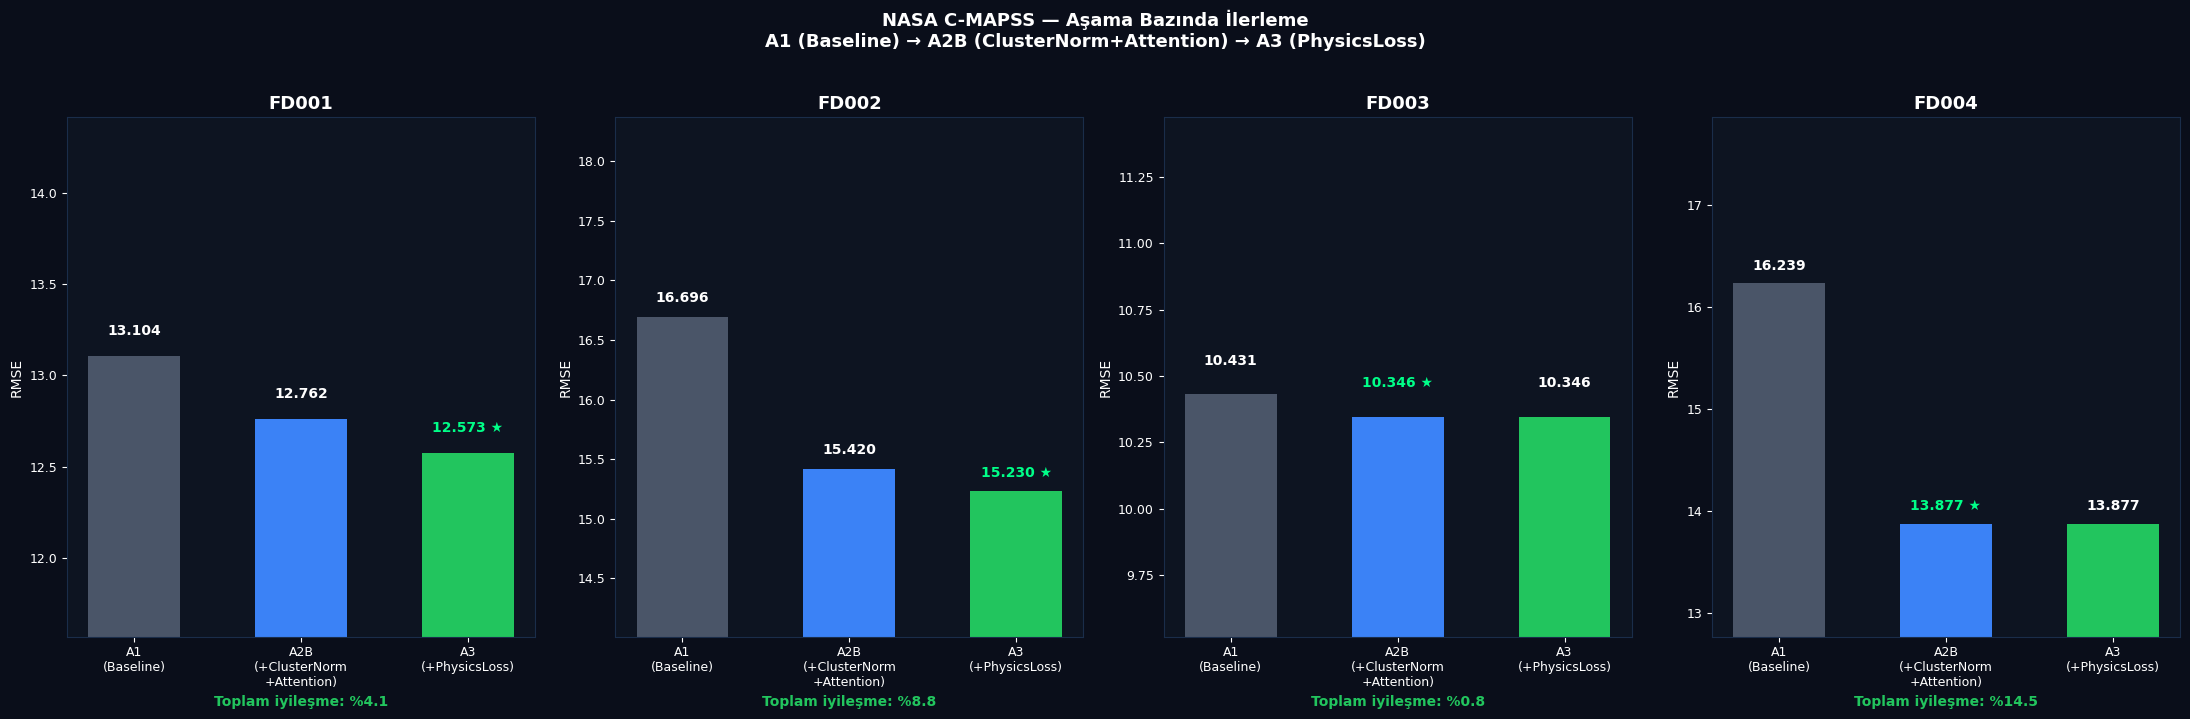

✓ İlerleme grafiği: /content/drive/MyDrive/cmapss_final/final_progress.png

[2/3] Literatür karşılaştırma grafiği...


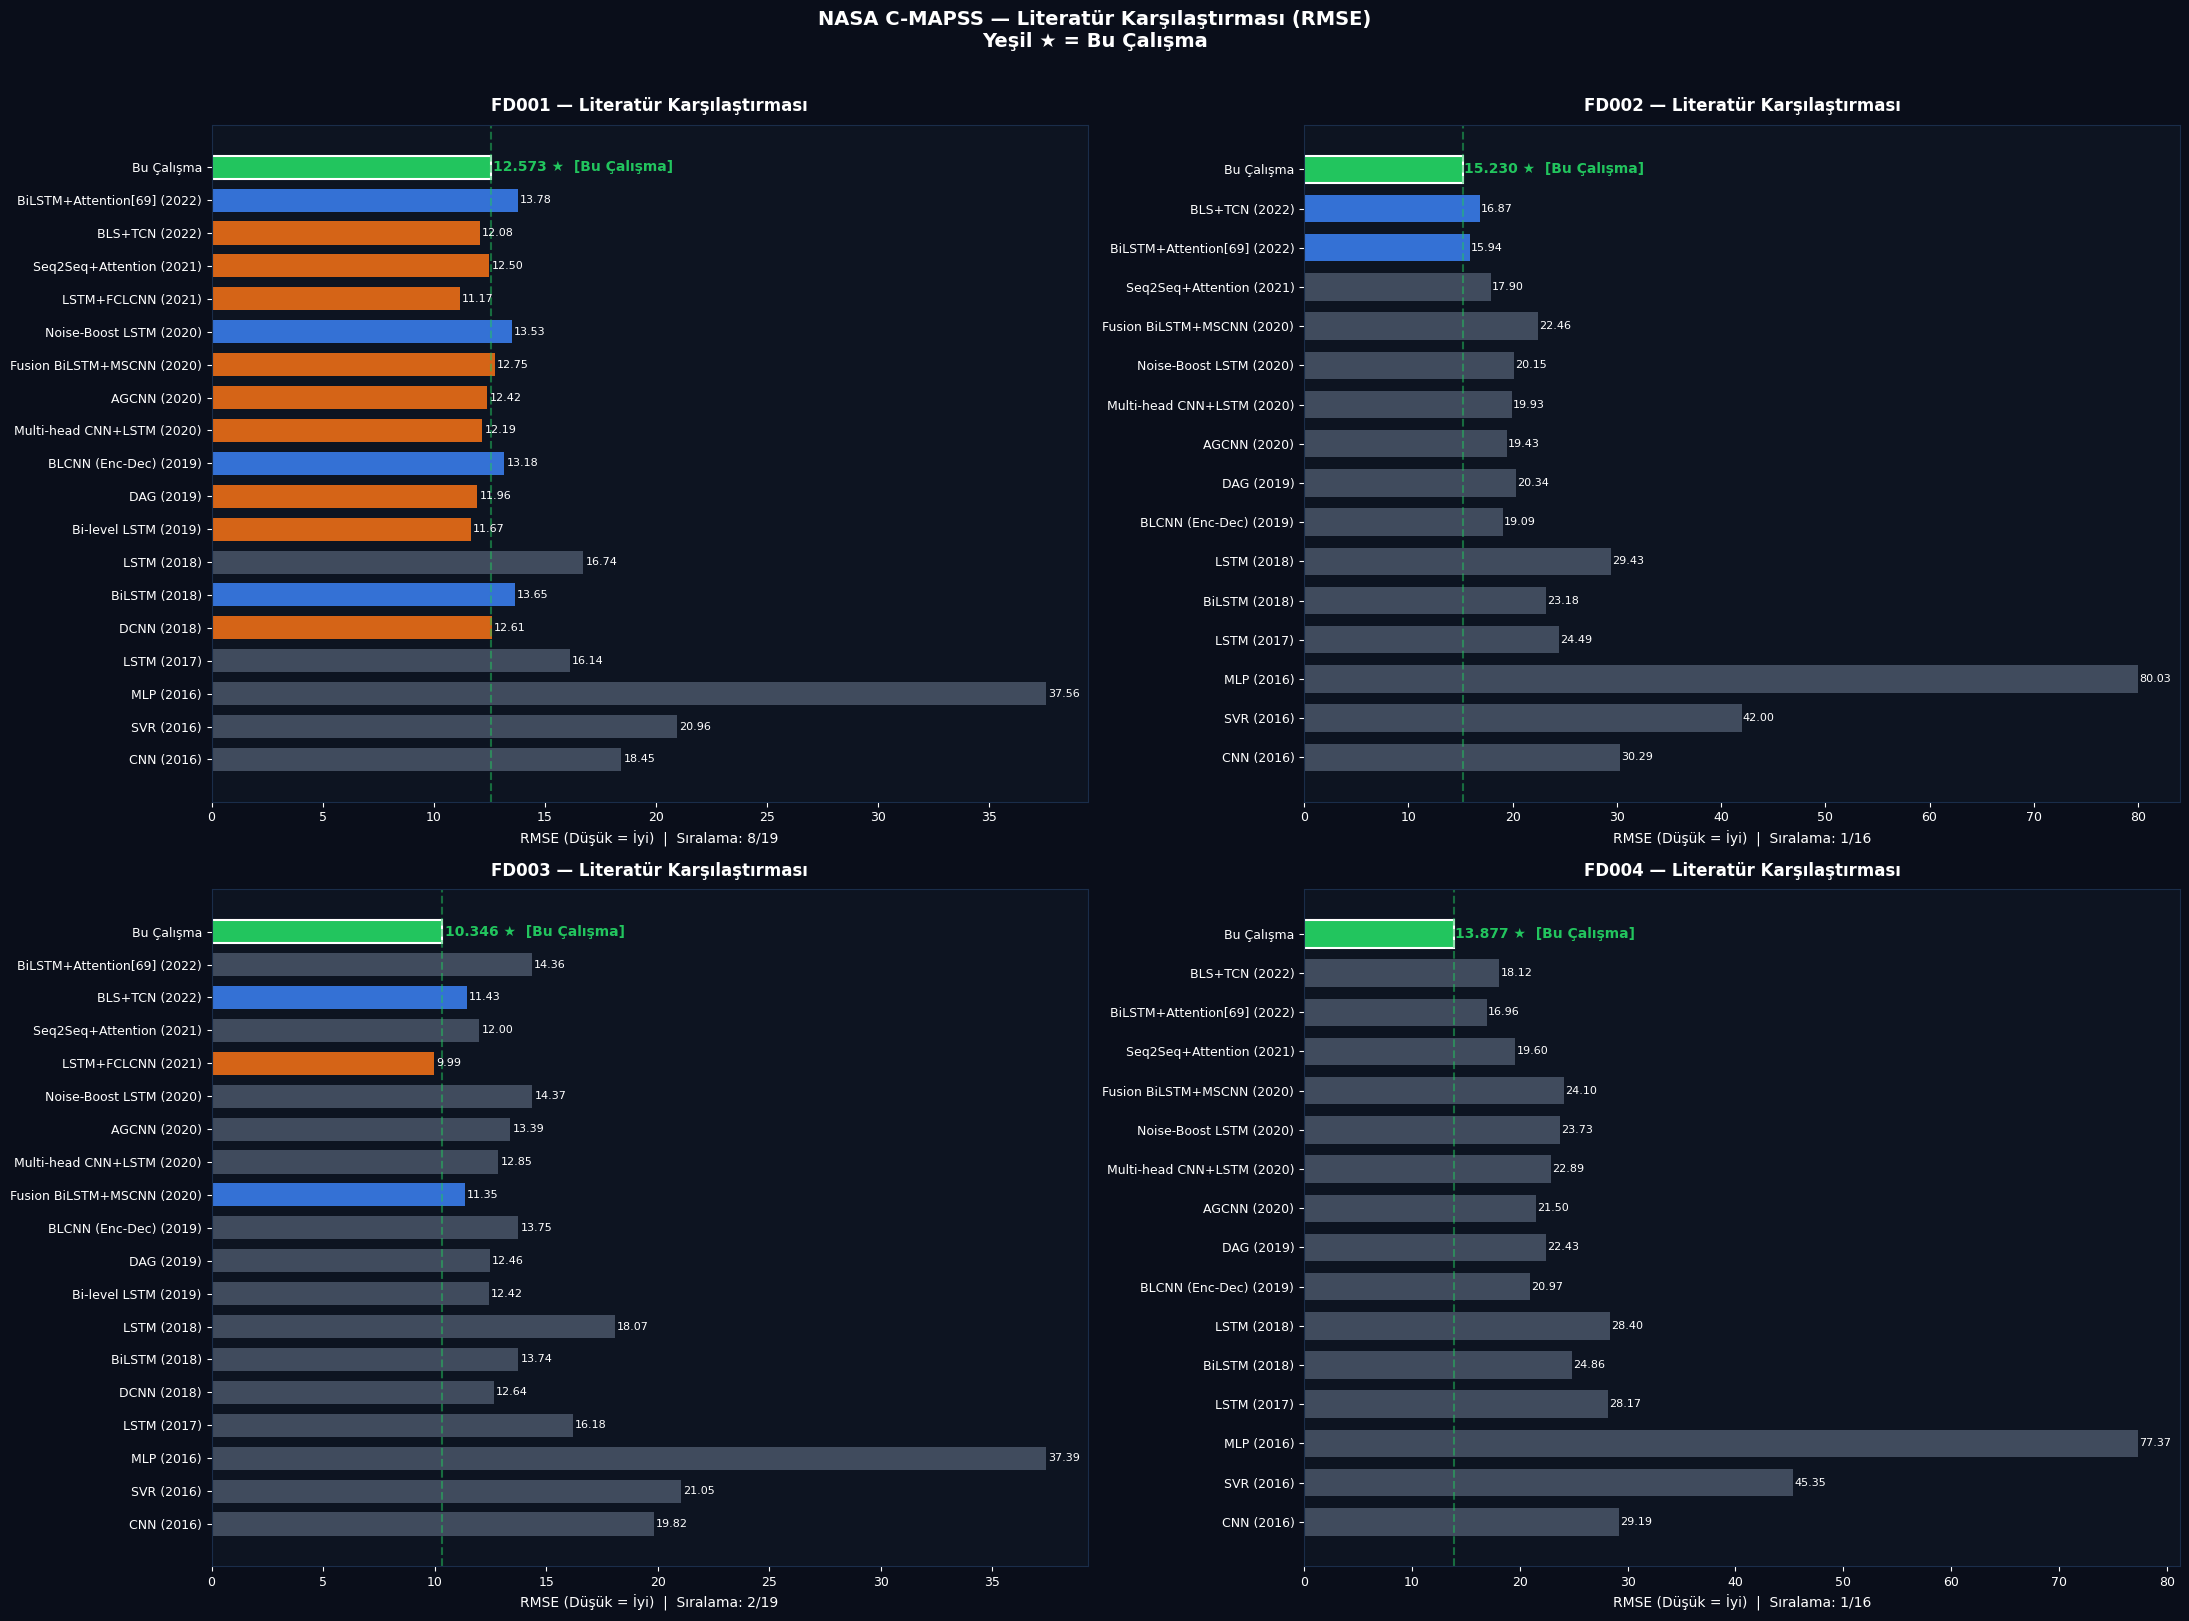

✓ Literatür karşılaştırma: /content/drive/MyDrive/cmapss_final/final_literature_rmse.png

[3/3] Final tahmin grafiği...


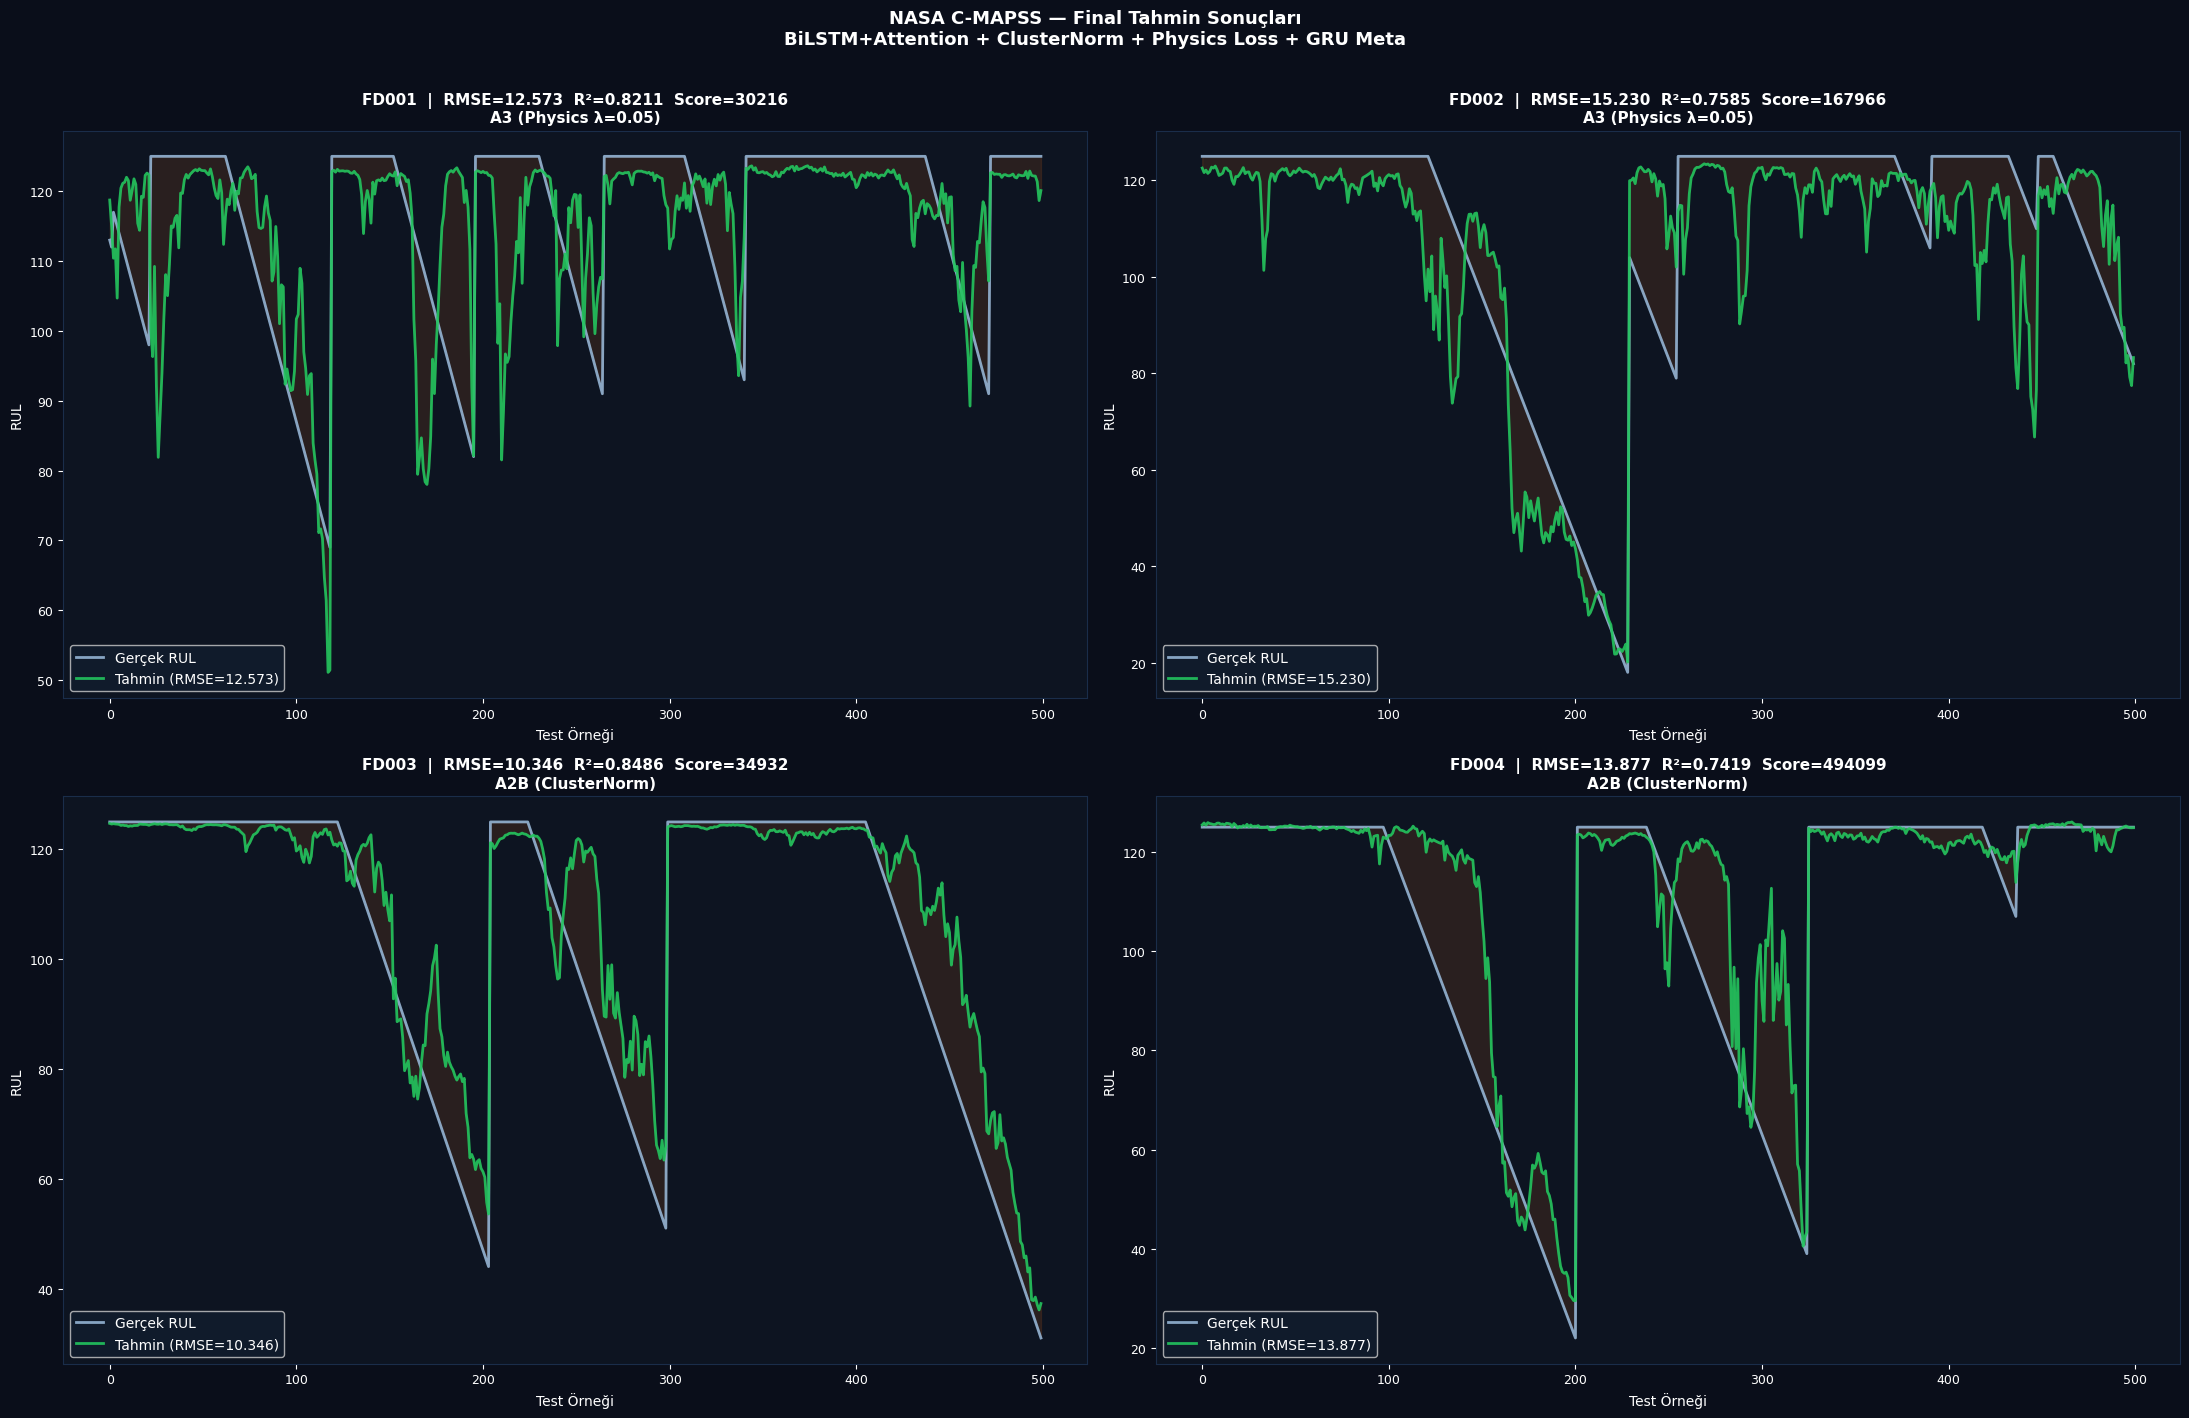

✓ Final tahmin grafiği: /content/drive/MyDrive/cmapss_final/final_predictions.png


In [9]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 8 — Ana Çalıştır                         ║
# ╚══════════════════════════════════════════════════╝

print("\n[1/3] Aşama ilerleme grafiği...")
plot_progress()

print("\n[2/3] Literatür karşılaştırma grafiği...")
plot_literature_comparison()

print("\n[3/3] Final tahmin grafiği...")
plot_final_predictions()

In [15]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 9 — Özet Tablo (Konsol + CSV)            ║
# ╚══════════════════════════════════════════════════╝

print(f"\n{'='*80}")
print(f"  FİNAL SONUÇLAR — TÜM SUBSETLER")
print(f"{'='*80}")
print(f"  {'Subset':<8} {'RMSE':>8} {'R²':>8} {'Score':>12} {'Kaynak':<25} {'Pipeline'}")
print(f"  {'─'*75}")
for subset in ['FD001','FD002','FD003','FD004']:
    m  = final_metrics[subset]
    or_ = OUR_RESULTS[subset]
    print(f"  {subset:<8} {m['RMSE']:>8.3f} {m['R2']:>8.4f} "
          f"{m['Score']:>12.1f}  {or_['source']:<25}")

print(f"\n{'='*80}")
print(f"  LİTERATÜR SIRALAMASI")
print(f"{'='*80}")
print(f"  {'Subset':<8} {'Bizim':>8} {'En İyi Lit.':>12} {'Fark':>8} {'Sıra':>6}")
print(f"  {'─'*50}")
for subset, rkey in zip(['FD001','FD002','FD003','FD004'],
                         ['fd001_rmse','fd002_rmse','fd003_rmse','fd004_rmse']):
    our  = final_metrics[subset]['RMSE']
    lits = [l[rkey] for l in LITERATURE if l[rkey] is not None]
    best_lit = min(lits)
    all_r    = sorted(lits + [our])
    rank     = all_r.index(our) + 1
    diff     = our - best_lit
    diff_str = f'+{diff:.3f}' if diff > 0 else f'{diff:.3f}'
    print(f"  {subset:<8} {our:>8.3f} {best_lit:>12.3f} {diff_str:>8} "
          f"{rank:>4}/{len(all_r)}")

# A1 → Final kümülatif iyileşme
print(f"\n{'='*80}")
print(f"  KÜMÜLATİF İYİLEŞME (A1 → Final)")
print(f"{'='*80}")
A1 = {'FD001':13.104,'FD002':16.696,'FD003':10.431,'FD004':16.239}
print(f"  {'Subset':<8} {'A1':>8} {'A2B':>8} {'Final':>8} {'İyileşme':>10}")
print(f"  {'─'*50}")
for subset in ['FD001','FD002','FD003','FD004']:
    a1  = A1[subset]
    a2b = PROGRESS[subset]['A2B']
    fin = final_metrics[subset]['RMSE']
    iy  = (a1 - fin) / a1 * 100
    print(f"  {subset:<8} {a1:>8.3f} {a2b:>8.3f} {fin:>8.3f} %{iy:>8.1f} ✓")

# CSV kaydet
rows = []
for subset in ['FD001','FD002','FD003','FD004']:
    m   = final_metrics[subset]
    or_ = OUR_RESULTS[subset]
    rows.append({
        'Subset':  subset,
        'RMSE':    round(m['RMSE'],4),
        'MAE':     round(m['MAE'],4),
        'R2':      round(m['R2'],4),
        'Score':   round(m['Score'],1),
        'Source':  or_['source'],
        'Pipeline':or_['pipeline'],
        'A1_RMSE': A1[subset],
        'A2B_RMSE':PROGRESS[subset]['A2B'],
        'Improvement_pct': round((A1[subset]-m['RMSE'])/A1[subset]*100, 2),
    })
df_final = pd.DataFrame(rows)
df_final.to_csv(os.path.join(SAVE_ROOT,'final_results.csv'), index=False)
print(f"\n✓ Final CSV: {SAVE_ROOT}/final_results.csv")

# Literatür karşılaştırma CSV
lit_rows = []
for l in LITERATURE:
    lit_rows.append({
        'Method': l['method'], 'Year': l['year'],
        'FD001': l['fd001_rmse'], 'FD002': l['fd002_rmse'],
        'FD003': l['fd003_rmse'], 'FD004': l['fd004_rmse'],
    })
# Bizim sonuçlarımızı ekle
lit_rows.append({
    'Method': 'Bu Çalışma (BiLSTM+Attn+ClusterNorm+PhysLoss+GRUMeta)',
    'Year': 2024,
    'FD001': final_metrics['FD001']['RMSE'],
    'FD002': final_metrics['FD002']['RMSE'],
    'FD003': final_metrics['FD003']['RMSE'],
    'FD004': final_metrics['FD004']['RMSE'],
})
pd.DataFrame(lit_rows).to_csv(
    os.path.join(SAVE_ROOT,'literature_comparison.csv'), index=False)
print(f"✓ Literatür CSV: {SAVE_ROOT}/literature_comparison.csv")

print(f"\n{'='*65}")
print(f"  FİNAL PİPELİNE TAMAMLANDI")
print(f"  Tüm çıktılar: {SAVE_ROOT}")
print(f"{'='*65}")



  FİNAL SONUÇLAR — TÜM SUBSETLER
  Subset       RMSE       R²        Score Kaynak                    Pipeline
  ───────────────────────────────────────────────────────────────────────────
  FD001      12.573   0.8211      30216.2  A3 (Physics λ=0.05)      
  FD002      15.230   0.7585     167965.9  A3 (Physics λ=0.05)      
  FD003      10.346   0.8486      34932.0  A2B (ClusterNorm)        
  FD004      13.877   0.7419     494099.1  A2B (ClusterNorm)        

  LİTERATÜR SIRALAMASI
  Subset      Bizim  En İyi Lit.     Fark   Sıra
  ──────────────────────────────────────────────────
  FD001      12.573       11.170   +1.403    8/19
  FD002      15.230       15.940   -0.710    1/16
  FD003      10.346        9.990   +0.356    2/19
  FD004      13.877       16.960   -3.083    1/16

  KÜMÜLATİF İYİLEŞME (A1 → Final)
  Subset         A1      A2B    Final   İyileşme
  ──────────────────────────────────────────────────
  FD001      13.104   12.762   12.573 %     4.1 ✓
  FD002      16.696   

In [14]:
# ╔══════════════════════════════════════════════════╗
# ║  HÜCRE 9 — Grafik 4: Bizim NASA Skorlarımız     ║
# ╚══════════════════════════════════════════════════╝

def plot_our_nasa_scores(final_metrics):
    fig, ax = plt.subplots(figsize=(10, 6), facecolor='#0a0e1a')
    BG='#0d1421'; TXT='white'
    C_SCORE='#00ff88' # Green for scores

    ax.set_facecolor(BG)
    ax.tick_params(colors=TXT, labelsize=9)
    for sp in ax.spines.values(): sp.set_edgecolor('#1a2d4a')

    subsets = ['FD001', 'FD002', 'FD003', 'FD004']
    scores = [final_metrics[s]['Score'] for s in subsets]

    bars = ax.bar(subsets, scores, color=C_SCORE, edgecolor='none', width=0.6)

    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10000, # Adjust Y for text position
                f'{bar.get_height():.1f}', ha='center', va='bottom', color=TXT, fontsize=10)

    ax.set_title('NASA C-MAPSS — Final NASA Skorları (Düşük = İyi)',
                 color=TXT, fontsize=13, fontweight='bold', pad=15)
    ax.set_ylabel('NASA Score', color=TXT)
    ax.set_xlabel('Subset', color=TXT)

    # Add a note about missing literature comparison data
    ax.text(0.5, -0.2, 'Not: Literatür karşılaştırma verisi (NASA Skoru) mevcut değildir.',
            horizontalalignment='center', verticalalignment='center',
            transform=ax.transAxes, color='gray', fontsize=9, fontstyle='italic')

    plt.tight_layout()
    out = os.path.join(SAVE_ROOT, 'final_nasa_scores.png')
    plt.savefig(out, dpi=150, bbox_inches='tight', facecolor='#0a0e1a')
    plt.show(); plt.close()
    print(f"✓ NASA Skorları grafiği: {out}")